# Logistic Regression

## Why not just use linear regression for classification?

When our outcome variable is a category — like "default/no default," "up day/down day," or "disease/no disease" — linear regression runs into trouble.

Imagine trying to predict whether someone will default on their credit card. We might code "Yes" as 1 and "No" as 0. If we fit a straight line, the line can happily predict values like 1.7 or -0.3. But those can't be interpreted as probabilities — probabilities have to stay between 0 and 1. For extreme values of the predictor, linear regression will confidently produce nonsense.

There's also a conceptual issue with multiple categories. If we have three diagnoses — stroke, drug overdose, epileptic seizure — and code them 1, 2, 3, we're implying that "drug overdose is exactly halfway between stroke and epileptic seizure," which is meaningless.

For binary outcomes (two categories), we need a model that produces values between 0 and 1 for any input, and logistic regression is the standard solution.

## The logistic function: squashing any value into 0-1

The logistic function takes any number — positive, negative, very large, very small — and maps it to a value between 0 and 1. Here's the intuition:

- For very negative inputs, the output is close to 0.
- For very positive inputs, the output is close to 1.
- At input 0, the output is exactly 0.5.
- The transition is smooth and S-shaped.

Under the hood, logistic regression is doing the same linear combination as linear regression — it computes a weighted sum of the predictors — but then wraps it in the logistic function to keep the output in bounds.

## How to interpret the coefficients

In linear regression, a coefficient of 3 means "for each one-unit increase in the predictor, the outcome goes up by 3." Logistic regression is a bit different because the function is non-linear.

What the coefficients represent is the effect on the **log-odds** — the logarithm of the ratio of the probability of "Yes" to the probability of "No." This is less intuitive, but the direction is still interpretable:

- A positive coefficient means that as the predictor increases, the probability of "Yes" goes up.
- A negative coefficient means that as the predictor increases, the probability of "Yes" goes down.
- A coefficient of zero means the predictor has no effect.

The magnitude tells you the strength of the effect, but to translate it into a change in probability, you need to account for the non-linear shape of the logistic function.

## The decision boundary

Once the model assigns a probability to each observation, we need a rule to classify it. The most common threshold is 0.5: if the predicted probability is above 0.5, predict "Yes"; otherwise predict "No."

This threshold defines a **decision boundary** — the point in predictor space where the model switches its prediction. Changing the threshold shifts this boundary:

- A lower threshold (like 0.3) makes the model predict "Yes" more often — catching more true positives, but also generating more false positives.
- A higher threshold (like 0.7) makes the model more conservative — fewer false positives but more missed cases.

The right threshold depends on the cost of each type of error in your specific application.

## Reading the confusion matrix and classification metrics

After making predictions, we evaluate them with a **confusion matrix** — a 2x2 table that shows how many observations fell into each combination of actual and predicted class.

From this we can compute:

- **Accuracy**: the fraction of predictions that were correct. Simple, but can be misleading when classes are imbalanced (e.g., 95% of cases are "No," so always predicting "No" gives 95% accuracy without learning anything).
- **Precision**: of all the cases we *predicted* as "Yes," what fraction actually were? High precision means when we say "Yes," we're usually right.
- **Recall** (also called sensitivity or true positive rate): of all the *actual* "Yes" cases, what fraction did we catch? High recall means we're not missing many real positives.

Precision and recall often trade off against each other. The ROC curve and AUC (area under the curve) let us evaluate a classifier across all possible thresholds at once, rather than locking in a single number.

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.linear_model as skl_lm
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn import preprocessing
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set(font_scale=1.25)
plt.rc('figure', figsize=(25, 9))
plt.style.use('seaborn-v0_8-white')
np.set_printoptions(precision=4, suppress=True)

## Default Data

The Default data set has a response variable, default, with two categories, Yes or No. There is one qualitative predictor, student, and two quantitative predictors, balance and income.

> Add blockquote



In [3]:
url1 = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Default.csv'
df = pd.read_csv(url1).drop('Unnamed: 0', axis='columns')

# Note: factorize() returns two objects: a label array and an array with the unique values.
# We are only interested in the first object.
df['default2'] = df.default.factorize()[0]
df['student2'] = df.student.factorize()[0]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   default   10000 non-null  object 
 1   student   10000 non-null  object 
 2   balance   10000 non-null  float64
 3   income    10000 non-null  float64
 4   default2  10000 non-null  int64  
 5   student2  10000 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 468.9+ KB


In [4]:
df.head()

,default,student,balance,income,default2,student2
0,No,No,729.526495,44361.62507,0,0
1,No,Yes,817.180407,12106.13470,0,1
2,No,No,1073.549164,31767.13895,0,0
3,No,No,529.250605,35704.49394,0,0
4,No,No,785.655883,38463.49588,0,0


The chart on the left shows annual incomes and monthly credit card balances, with defaulting individuals in orange and non-defaulters in blue. On the right, we have boxplots of balance and income split by whether or not someone defaulted. 

(0.0, 74567.24987765)

Text(0, 0.5, 'Income')

(-100.0, 2787.0387048000002)

Text(0.5, 0, 'Balance')

<Axes: xlabel='default', ylabel='balance'>

<Axes: xlabel='default', ylabel='income'>

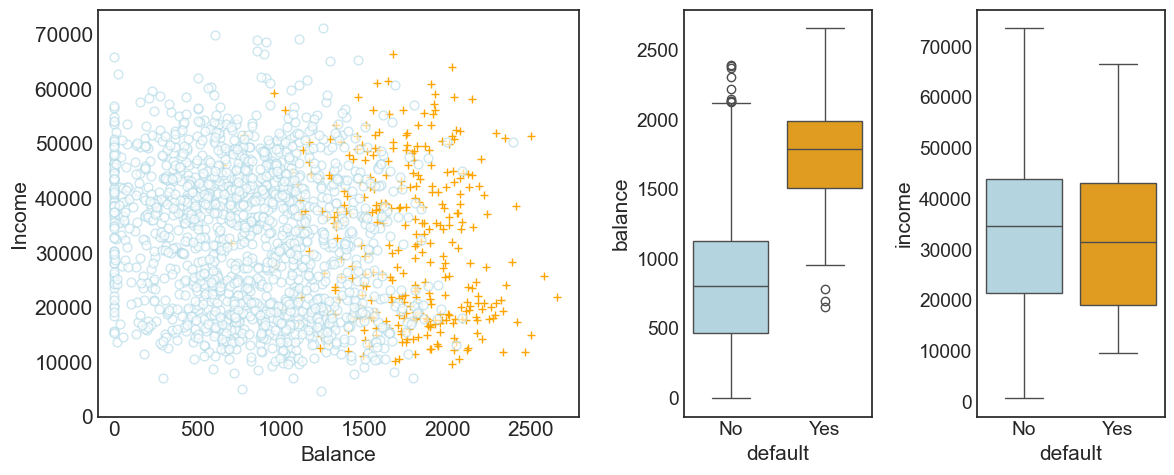

In [5]:
fig = plt.figure(figsize=(12,5))
gs = mpl.gridspec.GridSpec(1, 4)
ax1 = plt.subplot(gs[0,:-2])
ax2 = plt.subplot(gs[0,-2])
ax3 = plt.subplot(gs[0,-1])

# Take a fraction of the samples where target value (default) is 'no'
df_no = df[df.default == 'No'].sample(frac=0.15)
# Take all samples  where target value is 'yes'
df_yes = df[df.default == 'Yes']
df_ = pd.concat([df_no, df_yes])

ax1.scatter(x = df_[df_.default == 'Yes'].balance, y = df_[df_.default == 'Yes'].income, s=40, c='orange', marker='+',
            linewidths=1)
ax1.scatter(x = df_[df_.default == 'No'].balance, y = df_[df_.default == 'No'].income, s=40, marker='o', linewidths=1,
            edgecolors='lightblue', facecolors='white', alpha=.6)

ax1.set_ylim(ymin=0)
ax1.set_ylabel('Income', fontsize=15)
ax1.set_xlim(xmin=-100)
ax1.set_xlabel('Balance', fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=15)

c_palette = {'No':'lightblue', 'Yes':'orange'}
sns.boxplot(x = 'default', y = 'balance', data=df, orient='v', ax=ax2, palette=c_palette, hue='default', legend=False)
sns.boxplot(x = 'default', y = 'income', data=df, orient='v', ax=ax3, palette=c_palette, hue='default', legend=False)




gs.tight_layout(plt.gcf())



### Logistic Regression

Defaults appear pretty uniform across income, but split by balance, so we will first consider modeling the probability of default based on balance.

Though it may be natural to try and use linear regression, we can get some negative porbability estimates, as shown on the left. Logistic regression produces the probabilities on the right, which  fall between 0 and 1 and seem to better reflect the data. 

LogisticRegression()

<Axes: xlabel='balance', ylabel='default2'>

Text(0, 0.5, 'Probability of default')

Text(0.5, 0, 'Balance')

(-100.0, 2787.0387048000002)

Text(0, 0.5, 'Probability of default')

Text(0.5, 0, 'Balance')

(-100.0, 2787.0387048000002)

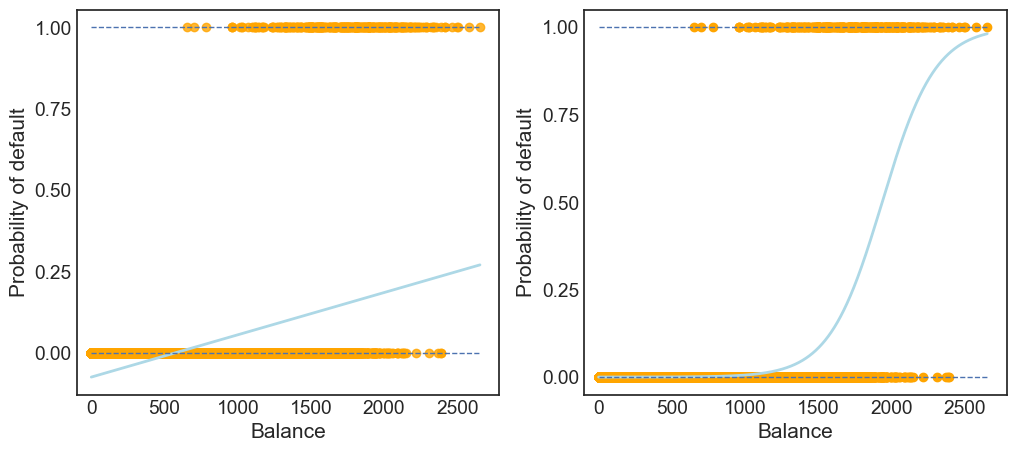

In [6]:
X_train = df.balance.values.reshape(-1,1)
y = df.default2

# Create array of test data. Calculate the classification probability
# and predicted classification.
X_test = np.arange(df.balance.min(), df.balance.max()).reshape(-1,1)

clf = skl_lm.LogisticRegression(solver='lbfgs')
clf.fit(X_train,y)
prob = clf.predict_proba(X_test)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
# Left plot
sns.regplot(x = df.balance, y = df.default2, order=1, ci=None,
            scatter_kws={'color':'orange'},
            line_kws={'color':'lightblue', 'lw':2}, ax=ax1)
# Right plot
ax2.scatter(X_train, y, color='orange')
ax2.plot(X_test, prob[:,1], color='lightblue', lw=2)

for ax in fig.axes:
    ax.hlines(1, xmin=ax.xaxis.get_data_interval()[0],
              xmax=ax.xaxis.get_data_interval()[1], linestyles='dashed', lw=1)
    ax.hlines(0, xmin=ax.xaxis.get_data_interval()[0],
              xmax=ax.xaxis.get_data_interval()[1], linestyles='dashed', lw=1)
    ax.set_ylabel('Probability of default')
    ax.set_xlabel('Balance')
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.])
    ax.set_xlim(xmin=-100)

Let's explore what's going on with this Logistic Regression.

In [7]:
y = df.default2
clf = skl_lm.LogisticRegression(solver='lbfgs')
X_train = df.balance.values.reshape(-1,1)
clf.fit(X_train,y)
print('\n')
print(clf)
print('classes: ',clf.classes_)
print('coefficients: ',clf.coef_)
print('intercept :', clf.intercept_)

LogisticRegression()



LogisticRegression()
classes:  [0 1]
coefficients:  [[0.0055]]
intercept : [-10.6513]


#### Try it yourself: the logistic curve and decision boundary

The slider below lets you adjust the decision threshold. Notice how changing the threshold moves the vertical line that separates "predict default" from "predict no default." A lower threshold catches more defaults but also flags more non-defaulters as risky.

In [20]:
import ipywidgets as widgets
from ipywidgets import interact

# Fit the model once for the interactive widget
from sklearn.linear_model import LogisticRegression as LR
_X = df.balance.values.reshape(-1, 1)
_y = df.default2
_logit_model = LR(solver='lbfgs')
_logit_model.fit(_X, _y)

balance_range = np.linspace(df.balance.min(), df.balance.max(), 500).reshape(-1, 1)
prob_curve = _logit_model.predict_proba(balance_range)[:, 1]

@interact(threshold=widgets.FloatSlider(min=0.05, max=0.95, step=0.05, value=0.5, description='Threshold'))
def plot_logistic_with_threshold(threshold):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: the S-curve with threshold line
    ax = axes[0]
    ax.plot(balance_range, prob_curve, color='blue', linewidth=2, label='Predicted probability')
    ax.axhline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
    # Find balance value where probability crosses threshold
    cross_idx = np.searchsorted(prob_curve, threshold)
    if cross_idx < len(balance_range):
        ax.axvline(balance_range[cross_idx], color='orange', linestyle=':', linewidth=2,
                   label=f'Decision boundary ≈ ${balance_range[cross_idx][0]:.0f}')
    ax.scatter(df.balance, df.default2, color='gray', alpha=0.05, s=5)
    ax.set_xlabel('Credit Card Balance ($)', fontsize=13)
    ax.set_ylabel('Probability of Default', fontsize=13)
    ax.set_title('Logistic Curve and Decision Boundary', fontsize=14)
    ax.legend(fontsize=11)

    # Right: confusion matrix stats at this threshold
    preds = (_logit_model.predict_proba(_X)[:, 1] >= threshold).astype(int)
    actual = _y.values
    tp = ((preds == 1) & (actual == 1)).sum()
    fp = ((preds == 1) & (actual == 0)).sum()
    tn = ((preds == 0) & (actual == 0)).sum()
    fn = ((preds == 0) & (actual == 1)).sum()
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    accuracy_val = (tp + tn) / len(actual)

    ax2 = axes[1]
    cm_data = np.array([[tp, fn], [fp, tn]])
    im = ax2.imshow(cm_data, cmap='Oranges')
    for i, row_label in enumerate(['Predicted Default', 'Predicted No Default']):
        for j, col_label in enumerate(['Actual Default', 'Actual No Default']):
            ax2.text(j, i, cm_data[i, j], ha='center', va='center', fontsize=14, color='black')
    ax2.set_xticks([0, 1]); ax2.set_xticklabels(['Actual Default', 'Actual No Default'])
    ax2.set_yticks([0, 1]); ax2.set_yticklabels(['Predicted Default', 'Predicted No Default'])
    ax2.set_title(f'Accuracy={accuracy_val:.2%}  Precision={precision_val:.2%}  Recall={recall_val:.2%}', fontsize=12)

    plt.tight_layout()
    plt.show()

LogisticRegression()

interactive(children=(FloatSlider(value=0.5, description='Threshold', max=0.95, min=0.05, step=0.05), Output()…

Just like with Linear Regression, scikit-learn gives us the coefficients but if we want to know more, we should use statsmodels.

In [9]:
est = smf.logit('default2 ~ balance', df).fit()
est.summary()

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               default2   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.4534
Time:                        15:36:52   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.6513      0.361    -29.491      0.000     -11.359      -9.943
balance        0.0055      0.000     24.952      0.000       0.005       0.006
==============================================================================

Possibly complete quasi-separation: A fraction 0.13 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

Here we get the same coefficient and intercept, but we also see our p-value indicates that balance is statistically significant. Since the coefficient is positive, we expect individuals with higher balances are more likely to default.

In [10]:
est.predict({'balance': 1000})

0    0.005752
dtype: float64

This model predicts that someone with a balance of $1000 has a 0.00575 probability of defaulting.

### Qualitative Predictors

We could also evaluate the probability of default based on student status, as shown in Table 4.2.

In [11]:
est = smf.logit('default2 ~ student', df).fit()
est.summary()

Optimization terminated successfully.
         Current function value: 0.145434
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               default2   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                0.004097
Time:                        15:36:52   Log-Likelihood:                -1454.3
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                 0.0005416
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.5041      0.071    -49.554      0.000      -3.643      -3.366
student[T.Yes]     0.4049      0.115      3.520      0.000       0.179       0.630
==================================================================================
"""

Here, student status is statistically significant, and the coefficient is postiive, meaning a student is more likely to default than a non-student.

In [12]:
est.predict({'student': 'Yes'})

0    0.043139
dtype: float64

In [13]:
est.predict({'student': 'No'})

0    0.029195
dtype: float64

Based on this model, the probability that a student defaults is 0.0431 and the probability a non-student defaults is 0.0292.

### Multiple Logistic Regression

As in the case of linear regression, we can fit a multiple logistic regression.

In [14]:
est = smf.logit('default2 ~ balance + income + student', df).fit()
est.summary()

Optimization terminated successfully.
         Current function value: 0.078577
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               default2   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.4619
Time:                        15:36:53   Log-Likelihood:                -785.77
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                3.257e-292
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -10.8690      0.492    -22.079      0.000     -11.834      -9.904
student[T.Yes]    -0.6468      0.236     -2.738      0.006      -1.110      -0.184
balance            0.0057      0.000     24.737      0.000       0.005       0.006
income          3.033e-06    8.2e-06      0.370      0.712    -1.3e-05    1.91e-05
==================================================================================

Possibly complete quasi-separation: A fraction 0.15 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

With all three predictors, income is not statistically significant, as we guessed from the first scatterplot. The coefficient on student is negative now, which means a student is less likely to default, **for a fixed value of balance and income**. What could be going on here?

This is figure 4.3 in the book. The panel on the left shows that as balances rise, default rates rise with them. Also, at every balance, students have lower default rates than non-students. The dashed lines, showing overall default rates, show that students default more than non-students. What could be going on here? The right panel offers an explanation. We see that students typically have higher balances than non-students, which the left panel tells us is related to higher default rates. A student is riskier than a non-student if no information about their balance is known, but that student is less risky than a non-student with the same balance.

Optimization terminated successfully.
         Current function value: 0.078584
         Iterations 10


Text(0, 0.5, 'Default Rate')

Text(0.5, 0, 'Credit Card Balance')

(450.0, 2500.0)

<Axes: xlabel='student', ylabel='balance'>

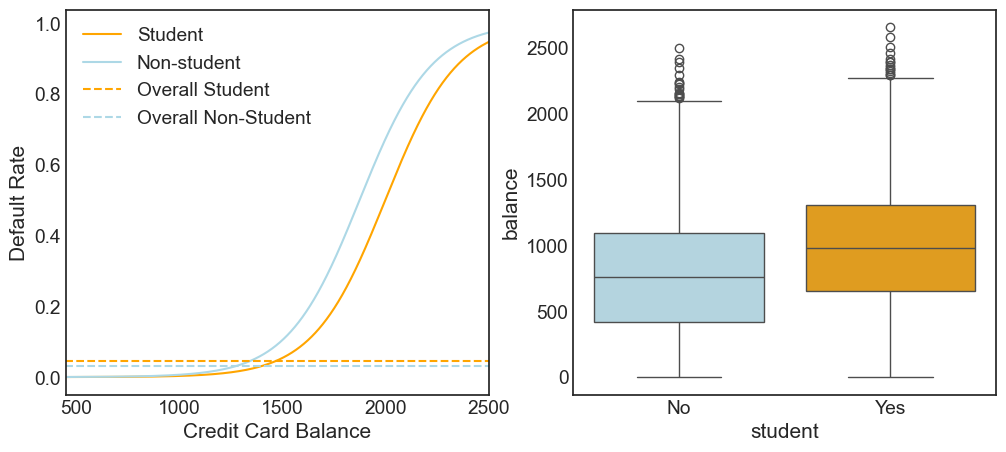

In [15]:
# Model fitting
est = smf.logit('default2 ~ balance + student', df).fit()

# Balance values for plot
bal = np.arange(df.balance.min(), df.balance.max()).reshape(-1,1)

# Student and Non-student probabilities of default
student_probs = [est.predict({'student': 'Yes', 'balance': b})[0] for b in bal]
non_student_probs = [est.predict({'student': 'No', 'balance': b})[0] for b in bal]

# Plotting figure
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

# Left plot
ax1.plot(bal, student_probs, color='orange', label='Student')
ax1.plot(bal, non_student_probs, color='lightblue', label='Non-student')
ax1.hlines(127/2817, colors='orange', label='Overall Student',
           xmin=ax1.xaxis.get_data_interval()[0],
           xmax=ax1.xaxis.get_data_interval()[1], linestyles='dashed')
ax1.hlines(206/6850, colors='lightblue', label='Overall Non-Student',
           xmin=ax1.xaxis.get_data_interval()[0],
           xmax=ax1.xaxis.get_data_interval()[1], linestyles='dashed')
ax1.set_ylabel('Default Rate')
ax1.set_xlabel('Credit Card Balance')
ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.])
ax1.set_xlim(450,2500)
ax1.legend(loc=2)

# Right plot
sns.boxplot(x='student', y='balance', data=df, orient='v', ax=ax2,  palette=c_palette, hue='student', legend=False)

Remember that logistic regression is essentially a linear regression with a logistic function wrapped around it. This means you could extend to polynomial functions, interaction terms, and all of the usual tools of linear regression, just like we did here by extending to multiple linear regression.

## Interactive 3D View — All Three Predictors

The plot below shows all three input variables at once: balance (x), income (y), and student status (z, which is binary so points sit on two planes).

- **Muted points** = training set, colored by their true class
- **Bright diamond points** = test set, colored by the model's *predicted* class

The model runs in the full 3-dimensional feature space (unlike the 2D logistic curve above, which only used balance). Use the threshold slider to change the decision boundary and watch the test point colors update. At the default threshold of 0.5 almost no one gets classified as a defaulter — try lowering it to see what the model actually thinks is risky.

In [16]:
from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display

# Build feature matrix from all three predictors
X3 = df[['balance', 'income', 'student2']].values
y3 = df['default2'].values

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.3, random_state=42
)

model3d = LR(solver='lbfgs', max_iter=1000)
model3d.fit(X3_train, y3_train)
probs3d = model3d.predict_proba(X3_test)[:, 1]

TRAIN_COLORS = ['#7bafd4', '#f4a7b9']   # muted blue, muted pink
TEST_COLORS  = ['#0055ff', '#ff0066']   # bright blue, bright magenta
LABELS = ['No Default', 'Default']

out3d = widgets.Output()

def update3d(threshold):
    y_pred = (probs3d >= threshold).astype(int)
    acc = (y_pred == y3_test).mean()
    n_pred_default = y_pred.sum()

    with out3d:
        out3d.clear_output(wait=True)
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')

        # Training points — muted, small, semi-transparent
        for cls in range(2):
            mask = y3_train == cls
            ax.scatter(
                X3_train[mask, 0], X3_train[mask, 1], X3_train[mask, 2],
                c=TRAIN_COLORS[cls], s=15, alpha=0.25,
                label=f'Train · {LABELS[cls]}'
            )

        # Test points — bright, larger diamonds, black edge
        for cls in range(2):
            mask = y_pred == cls
            ax.scatter(
                X3_test[mask, 0], X3_test[mask, 1], X3_test[mask, 2],
                c=TEST_COLORS[cls], s=55, alpha=0.9, marker='D',
                edgecolors='black', linewidths=0.4,
                label=f'Test pred · {LABELS[cls]}'
            )

        ax.set_xlabel('Balance', fontsize=10)
        ax.set_ylabel('Income', fontsize=10)
        ax.set_zlabel('Student (0=No, 1=Yes)', fontsize=10)
        ax.set_title(
            f'Threshold = {threshold:.2f}  |  '
            f'Predicted defaults = {n_pred_default}  |  '
            f'Test accuracy = {acc:.2%}',
            fontsize=11
        )
        ax.legend(fontsize=9, loc='upper left')
        plt.tight_layout()
        plt.show()

thresh_slider = widgets.FloatSlider(
    value=0.5, min=0.05, max=0.95, step=0.05,
    description='Threshold',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px')
)

thresh_slider.observe(lambda _: update3d(thresh_slider.value), names='value')

display(widgets.VBox([thresh_slider, out3d]))
update3d(0.5)

LogisticRegression(max_iter=1000)